In [11]:
import torch as th
import numpy as np
import pandas as pd
import requests
from matplotlib import pyplot as plt
import uuid
import secrets
import os
from pathlib import Path

# Model Inference

In [ ]:
import requests

model_url = "http://localhost:8080/v1/chat/completions"

model_name = "model-name.gguf"
prompt = "Tell me an interesting fact about LLMs."
temperature = 0.7
max_tokens = 8192

# Defien the payload
payload = {"messages": [{"role": "user", "content": prompt}],
		   "streams": False}
		   
headers = {"Content-Type": "application/json"}

try:
    response = requests.post(model_url, json=payload)
    
    if response.status_code == 200:
        response_data = response.json()
        
        choices = response_data.get("choices", [])
        
        if choices:
            result = choices[0].get("text", "")
            print("Response:\n", result)
        else:
            print("No choices found in the response.")
    else:
        print(f"Request to the API failed with status code: {response.status_code}")
except Exception as e:
    print(f"Error occured: {e}")

Response:
 


In [ ]:
response.iter_lines()

In [1]:
model_url = "http://localhost:8080/v1/chat/completions"

In [11]:
def model(text, model_url):
    response = requests.post(model_url, json={"messages": [{"role": "user", "content": text}],
                                                "streams":False})
    return response.json()["choices"][0]['message']['content']

In [13]:
queries = ['How is cat?', 'How long cats live']
response = [model(query, model_url) for query in queries]

In [16]:
print(response[1])

The lifespan of domestic cats can vary significantly and is influenced by several factors including genetics, diet, health, and lifestyle. On average, domestic cats live around 12 to 18 years. Some cats have even lived into their mid-teens or older under ideal conditions. However, some factors that can affect their lifespan include:

1. **Genetics**: Some breeds are known for their longevity, such as Siamese, Norwegian Forest Cats, and Maine Coons. Other breeds may have a shorter typical lifespan.
2. **Diet**: A healthy, balanced diet is crucial. Too much or too little can affect a cat's health.
3. **Health**: Regular veterinary check-ups can help detect and treat health issues early, which is important for a cat's long-term health.
4. **Genetics**: Certain genetic diseases can shorten a cat’s lifespan.
5. **Living Environment**: A cat's environment, including housing and exercise opportunities, can impact its health and longevity.
6. **Behavior**: Cats that are more active and get ple

# Vector Database

In [2]:
emb_url = "http://localhost:8181/embedding"

In [3]:
filename = "cat-facts.txt"

with open(filename, 'r') as f:
    text_db = f.readlines()

In [4]:
text_db = np.array([x.strip("\n") for x in text_db])

In [5]:
vector_db = requests.post(emb_url, json={"content": list(text_db)})

In [6]:
# stack embedding vectors along the dim 1
# Each column is an embedding vector
vector_db = np.stack([np.array(x['embedding'][0]) for x in vector_db.json()], axis=1)

vector_db = {'vectors': vector_db, 'text': text_db}

In [12]:
[x.shape for x in vector_db.values()]

[(768, 150), (150,)]

# Vector Similarity

In [ ]:
emb_model = "bge-base-en-v1.5-f16.gguf"

In [7]:
def similarity(x, y):
    x = x/np.linalg.norm(x)
    y = y/np.linalg.norm(y)
    return np.dot(x.reshape(1,-1), y.reshape(-1,1)).item()

In [8]:
query = "How much cats sleep?"

query_vector = np.array(requests.post(emb_url, json={"content": query})\
                 .json()[0]['embedding'][0])

In [15]:
threshold = 0.66

similarity_score = np.matmul(query_vector, vector_db)
context = text_db[similarity_score>=threshold]

contextualized_query = "".join(context)+query

ValueError: matmul: Input operand 1 does not have enough dimensions (has 0, gufunc core with signature (n?,k),(k,m?)->(n?,m?) requires 1)

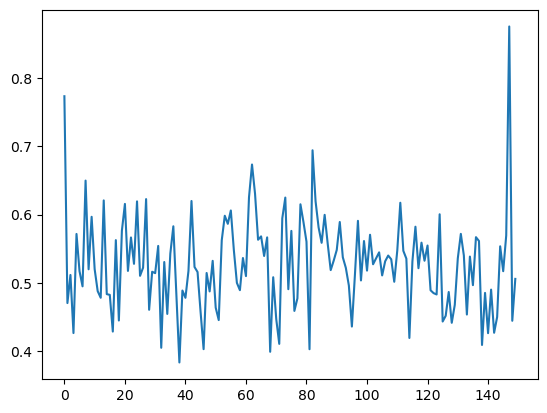

In [178]:
plt.plot(np.matmul(query_vector, vector_db))

# Inference

In [21]:
def embed_text(text, emb_url, return_numpy=True):
    try:
        embedding = requests.post(emb_url, json={'content': text})
        if embedding.status_code == 200:
            embedding = embedding.json()[0]['embedding'][0]
            if return_numpy:
                embedding = np.array(embedding).reshape(1,-1)
            return embedding
        else:
            print("Server responded null.")
    except Exception as e:
        print(f"Error occured: {e}")

In [10]:
def search_context(query_vector, vector_db):
    # define a threshold score for similarity.
    threshold = 0.66
    # calculate the similarity score of query vector against each vector in the database.
    similarity_score = np.matmul(query_vector, vector_db)
    
    indices = np.argmax(similarity_score>=threshold)
    
    return similarity_score, indices

In [31]:
query = "Must-haves in RAG projects?"

rag_response = rag(query, vector_db, emb_url, model_url)

print(rag_response['response'])

Based on the previous paragraph, the information is not available. The preceding text does not discuss "must-haves in RAG projects."


In [32]:
print(rag_response['context'])

In [329]:
query_vector = embed_text(query, emb_url)

In [336]:
np.argmax(np.matmul(query_vector, vector_db['vectors'])>0.6)

7

In [338]:
vector_db['text'][np.matmul(vector_db['vectors'][:,7], vector_db['vectors'])>0.6]

array(['The Pitch: A RAG system specifically for high-energy physics papers (arXiv).',
       'Why it clears the baseline: It proves you can handle complex data (LaTeX, equations, and dense academic PDFs) which standard "out-of-the-box" RAG often fails at.',
       'MLE "Flex": Use Hybrid Search (combining BM25 keyword search with Vector dense search) to ensure it finds specific mathematical terms that embeddings might blur together.',
       'MLE "Flex": Implement Self-RAG. Have the model critique its own retrieved context to see if it actually answers the user\'s travel query before it generates a response.',
       'Option 3: The "Code-Base Interpretability" RAG (Technical Focus)',
       'The Pitch: A RAG tool that indexes a complex physics simulation codebase (like something in SageMath or Cadabra) to help researchers understand the logic flow.',
       'Why it clears the baseline: Large-scale code retrieval is one of the hardest RAG problems in 2026.',
       'MLE "Flex": Show of

In [11]:
def search_context(query_vector, vector_db):
    D, I = vector_db.search(query_vector, 3)
    return D, I

In [12]:
def rag(query, vector_db, emb_url, model_url):
    # Embed the query
    query_vector = embed_text(query, emb_url)
    
    # search for the text that are relevant to the query and return their indices.
    _, context_indices = search_context(query_vector, vector_db['vectors'])
    # fetch the information using the indices.
    context = vector_db['text'][context_indices]
    context = "\n".join(context[0])
    
    instructions = """Based on context provided, respond only to what the query text says or asks. 
                      If the information the query text seeks is not present in the context text, without explanation say the information is not available.
                      However, if the information contradicts, say the same."""
    contextualized_query = f"""<instruction>
                            {instructions}
                            </instruction>
                            
                            <context>
                            {context}
                            </context>
                            
                            <query>
                            {query}
                            </query>"""
    
    model_response = model(contextualized_query, model_url)
    
    return {'response': model_response, 'context': context}

# Using FAISS

In [16]:
import faiss

In [53]:
index = faiss.IndexFlatIP(768)

In [ ]:
# To use GPU instead use the following.
rs = faiss.StandardGpuResources()
co = faiss.GpuClonerOptions()

index_gpu= faiss.index_cpu_to_gpu(provider=rs, device=0, index=index,  options=co)

In [54]:
# Use index_gpu to use index loaded on GPU.
index.add(vector_db['vectors'].T)

In [101]:
query = "How fast a cat can run?"

response = rag(query, {'text': vector_db['text'], 'vectors': index},
               emb_url, model_url)

In [102]:
print(response['response'])
print(f"""\nContext used:\n\n{response['context']}""")

A cat can travel at a top speed of approximately 31 mph (49 km) over a short distance.

Context used:

A cat can travel at a top speed of approximately 31 mph (49 km) over a short distance.
A cat’s heart beats nearly twice as fast as a human heart, at 110 to 140 beats a minute.
A cat can jump up to five times its own height in a single bound.


In [11]:
import os

os.environ['MATHEMATICA_HOME']

'/usr/local/Wolfram/WolframEngine/14.3'

# Using Qdrant DB

In [2]:
from qdrant_client import QdrantClient, models
from qdrant_client.models import Distance, VectorParams, Filter, FieldCondition, MatchValue
import uuid

In [14]:
db_path = "~/Documents/Numerical/AI\ ML/Projects/RAG/Database"

client = QdrantClient(path=db_path)

In [15]:
model_name = "bge-base-en-v1.5-f16"
collection_name = "cat_facts"

In [31]:
client.delete_collection(collection_name=collection_name)
client.collection_exists(collection_name=collection_name)

False

In [128]:
client.upload_collection(collection_name=collection_name,
                         vectors=vector_db['vectors'].T)

status=<CollectionStatus.GREEN: 'green'> optimizer_status=<OptimizersStatusOneOf.OK: 'ok'> warnings=None indexed_vectors_count=0 points_count=150 segments_count=1 config=CollectionConfig(params=CollectionParams(vectors=VectorParams(size=768, distance=<Distance.COSINE: 'Cosine'>, hnsw_config=None, quantization_config=None, on_disk=None, datatype=None, multivector_config=None), shard_number=None, sharding_method=None, replication_factor=None, write_consistency_factor=None, read_fan_out_factor=None, read_fan_out_delay_ms=None, on_disk_payload=None, sparse_vectors=None), hnsw_config=HnswConfig(m=16, ef_construct=100, full_scan_threshold=10000, max_indexing_threads=0, on_disk=None, payload_m=None, inline_storage=None), optimizer_config=OptimizersConfig(deleted_threshold=0.2, vacuum_min_vector_number=1000, default_segment_number=0, max_segment_size=None, memmap_threshold=None, indexing_threshold=20000, flush_interval_sec=5, max_optimization_threads=1, prevent_unoptimized=None), wal_config=Wa

In [24]:
print(str(results.points[0]).replace(" ", "\n"))

id='2951ed16-f3a8-4e88-a128-ad5db5a1b714'
version=0
score=0.8831771707832707
payload=None
vector=None
shard_key=None
order_value=None


## Uploading vectors in bulk

In [34]:
uuid_gen = np.vectorize(lambda x: str(uuid.uuid4()))

In [37]:
dim, num_vectors = vector_db['vectors'].shape
collection_name = 'cat_facts'

if client.collection_exists(collection_name=collection_name):
    client.delete_collection(collection_name=collection_name)
    
client.create_collection(collection_name=collection_name,
                         vectors_config=models.VectorParams(size=dim, distance=models.Distance.COSINE))

True

In [38]:
ids = uuid_gen(np.arange(num_vectors))

In [41]:
client.upload_collection(collection_name=collection_name,
                         vectors=vector_db['vectors'].T,
                         ids=ids.tolist())

In [42]:
query = embed_text('How long cats live?', emb_url=emb_url).flatten()

response = client.query_points(collection_name=collection_name, query=query, with_vectors=True)

In [51]:
matched_ids = np.array([point.id for point in response.points])

In [66]:
np.isin(ids, matched_ids)

array([ True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True, False, False, False, False,
        True, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
        True,  True, False, False, False, False, False, False, False,
       False, False,

In [56]:
vector_db['text'][np.isin(ids, matched_ids)]

array(['On average, cats spend 2/3 of every day sleeping. That means a nine-year-old cat has been awake for only three years of its life.',
       'Some cats have survived falls of over 65 feet (20 meters), due largely to their “righting reflex.” The eyes and balance organs in the inner ear tell it where it is in space so the cat can land on its feet. Even cats without a tail have this ability.',
       'Most cats give birth to a litter of between one and nine kittens. The largest known litter ever produced was 19 kittens, of which 15 survived.',
       'The earliest ancestor of the modern cat lived about 30 million years ago. Scientists called it the Proailurus , which means “first cat” in Greek. The group of animals that pet cats belong to emerged around 12 million years ago.',
       'The oldest cat on record was Crème Puff from Austin, Texas, who lived from 1967 to August 6, 2005, three days after her 38th birthday. A cat typically can live up to 20 years, which is equivalent to ab

In [58]:
[x.score for x in response.points]

[0.8831771728116093,
 0.8289753500916588,
 0.7491199136554736,
 0.7470578240449928,
 0.7117874366832504,
 0.7094526116518488,
 0.6951240920507196,
 0.6847508700281195,
 0.6798148151155352,
 0.6784674919695453]

# Uploading pipeline

In [3]:
def chunk(filename: str) -> list[str]:
    with open(filename, 'r') as file:
        text_db: list[str] = file.readlines()
        text_db: list[str] = [x.strip('\n') for x in text_db]
    return text_db

In [4]:
filename = "cat-facts.txt"

rdb: list[str] = chunk(filename)

In [5]:
emb_url = 'http://localhost:8181/embedding'

In [6]:
def embed_text(text:list[str], url:str, return_numpy:bool=False) -> list[list]:
    payload = {'content': text}
    try:
        response = requests.post(url=url, json=payload)
        status = response.status_code
        if status == 200:
            response = response.json()
            response = [x['embedding'][0] for x in response]
            if return_numpy:
                response = np.array(response)
            return response
        else:
            print(f"Server not responded. Error code: {status}")
            
    except Exception as e:
        print(f"Error occured while connecting to the embedding model at {url}: {e}")

In [7]:
np.array(embed_text(rdb[:3], emb_url)).shape

(3, 768)

In [8]:
NAMESPACE = uuid.UUID('2f07ce7c-f5fa-4ca3-afb7-9334e47aab56')

In [9]:
def generate_uuid(data: list[str], NAMESPACE: str) -> list[str]:
    ids = [str(uuid.uuid5(NAMESPACE, text)) for text in data]
    return ids

In [10]:
ids = generate_uuid(rdb, NAMESPACE)

In [11]:
db = pd.DataFrame(rdb, columns=['text'], index=ids).rename_axis('id')

In [12]:
vectors = embed_text(rdb, url=emb_url)

In [13]:
num_samples = len(vectors)
dim = len(vectors[0])

In [14]:
vector_db_path = '~/Documents/Numerical/AI\ ML/Projects/RAG/Database/'

client = QdrantClient(path=vector_db_path)

In [50]:
client.delete_collection(collection_name=collection_name)

True

In [67]:
collection_name = 'cat_facts'

if not client.collection_exists(collection_name=collection_name):
    client.create_collection(collection_name=collection_name,
                             vectors_config=models.VectorParams(size=dim, distance=models.Distance.COSINE))

In [19]:
client.upload_collection(collection_name=collection_name,
                         vectors=vectors,
                         ids=ids,
                         parallel=4)

In [20]:
client.retrieve(collection_name=collection_name,
                ids=[ids[10]])

[Record(id='449afddb-7723-5f50-9fd8-72856764b0d4', payload={}, vector=None, shard_key=None, order_value=None)]

In [21]:
db.head()

,text
id,
2fe4b814-e676-5f31-838a-c0d9fd868c4c,"On average, cats spend 2/3 of every day sleepi..."
079b5a19-ab2f-5cd8-ab7f-64e22cbfec86,"Unlike dogs, cats do not have a sweet tooth. S..."
640c3b8a-813c-50b5-b030-6757207d85c1,"When a cat chases its prey, it keeps its head ..."
b41fd209-bde9-5976-93d6-c7d0f1f82cef,The technical term for a cat’s hairball is a “...
adc48e2b-17cf-589e-83ee-5ef23a0b9680,A group of cats is called a “clowder.”


In [56]:
def create_rdb(filename: str, ID_NAMESPACE: str) -> pd.DataFrame:
    chunked_text = chunk(filename)
    
    #embedded_text = embed_text(chunked_text, url)
    
    ids = [str(uuid.uuid5(ID_NAMESPACE, text)) for text in chunked_text]
    
    embedded_text = pd.DataFrame(chunked_text, columns=['text'], index=ids).rename_axis('id')
    return embedded_text

In [57]:
db = create_rdb(filename, NAMESPACE)
db.head()

,text
id,
2fe4b814-e676-5f31-838a-c0d9fd868c4c,"On average, cats spend 2/3 of every day sleepi..."
079b5a19-ab2f-5cd8-ab7f-64e22cbfec86,"Unlike dogs, cats do not have a sweet tooth. S..."
640c3b8a-813c-50b5-b030-6757207d85c1,"When a cat chases its prey, it keeps its head ..."
b41fd209-bde9-5976-93d6-c7d0f1f82cef,The technical term for a cat’s hairball is a “...
adc48e2b-17cf-589e-83ee-5ef23a0b9680,A group of cats is called a “clowder.”


In [44]:
vectors = embed_text(db.text.values.tolist(), emb_url)

In [60]:
client.upload_collection(collection_name=collection_name,
                         vectors=vectors,
                         ids=db.index.to_list())

In [68]:
def upload_pipeline(raw_filename: str, ID_NAMESPACE: str, client: QdrantClient, collection_name: str):
    text_db = create_rdb(raw_filename, ID_NAMESPACE)
    
    raw_filepath = "~/Documents/Numerical/AI\ ML/Projects/RAG/Database/cat_facts.parquet"
    text_db.to_parquet(raw_filepath)
    
    emb_url = 'http://localhost:8181/embedding'
    vectors = embed_text(text_db.text.values.tolist(), emb_url)
    
    client.upload_collection(collection_name=collection_name,
                         vectors=vectors,
                         ids=db.index.to_list())

In [ ]:
upload_pipeline(filename, NAMESPACE, client, collection_name)

# Inference Pipeline

In [1]:
client.close()

NameError: name 'client' is not defined

In [66]:
query = ['How long do cats live?', 'What is the name of the cats?']

query_vector = embed_text(query, url=emb_url)

In [ ]:
response = client.query_points(collection_name=collection_name,
                               query=query_vector,)

In [130]:
queries = [models.QueryRequest(query=v) for v in query_vector]

response = client.query_batch_points(collection_name=collection_name,
                          requests=queries)

In [131]:
response

[QueryResponse(points=[ScoredPoint(id='8f396fa6-e198-506d-807a-28a646911215', version=0, score=0.883954607709276, payload=None, vector=None, shard_key=None, order_value=None), ScoredPoint(id='f470b6de-1e91-5712-95d3-364a72161799', version=0, score=0.8300629797152207, payload=None, vector=None, shard_key=None, order_value=None), ScoredPoint(id='2fe4b814-e676-5f31-838a-c0d9fd868c4c', version=0, score=0.7492976697371002, payload=None, vector=None, shard_key=None, order_value=None), ScoredPoint(id='3e79af9f-eb55-531c-a57f-de58f361a85a', version=0, score=0.7404423798574904, payload=None, vector=None, shard_key=None, order_value=None), ScoredPoint(id='9855a9f2-4ce1-588f-a147-09829819976d', version=0, score=0.7170034657687193, payload=None, vector=None, shard_key=None, order_value=None), ScoredPoint(id='70f13652-1446-5afa-acaf-03c356bfdc67', version=0, score=0.7073908047852165, payload=None, vector=None, shard_key=None, order_value=None), ScoredPoint(id='42f6d2eb-d0e3-5f55-9be4-b67baf0653b2',

In [133]:
matched_ids = [np.array([[point.id, point.score] for point in x.points]) for x in response]
matched_ids = [pd.DataFrame(match, columns=['id', 'score']).set_index('id') for match in matched_ids]

In [134]:
matched_ids

[                                                   score
 id                                                      
 8f396fa6-e198-506d-807a-28a646911215   0.883954607709276
 f470b6de-1e91-5712-95d3-364a72161799  0.8300629797152207
 2fe4b814-e676-5f31-838a-c0d9fd868c4c  0.7492976697371002
 3e79af9f-eb55-531c-a57f-de58f361a85a  0.7404423798574904
 9855a9f2-4ce1-588f-a147-09829819976d  0.7170034657687193
 70f13652-1446-5afa-acaf-03c356bfdc67  0.7073908047852165
 42f6d2eb-d0e3-5f55-9be4-b67baf0653b2  0.6921464347817221
 95a39935-a0b9-58b2-9409-09bd94957388  0.6887249929521102
 42626ada-9a17-56a8-b856-b159b09f8b6b  0.6868218930446255
 918f4d42-8604-54b0-aae8-ebeec643f253  0.6793369574637482,
                                                    score
 id                                                      
 adc48e2b-17cf-589e-83ee-5ef23a0b9680  0.7242026020187845
 85bfaaa3-7bba-5fe9-bfe3-8630d28bbed8  0.6784842904695132
 e88f25c2-70b9-52fa-96e2-b6236c9c5905  0.6766588417538161
 956a1268-79b

In [135]:
[matched.merge(db, on='id', how='left')['text'].values for matched in matched_ids]

[array(['When well treated, a cat can live twenty or more years but the average life span of a domestic cat is 14 years.',
        'The oldest cat on record was Crème Puff from Austin, Texas, who lived from 1967 to August 6, 2005, three days after her 38th birthday. A cat typically can live up to 20 years, which is equivalent to about 96 human years.',
        'On average, cats spend 2/3 of every day sleeping. That means a nine-year-old cat has been awake for only three years of its life.',
        'Neutering a cat extends its life span by two or three years.',
        'The earliest ancestor of the modern cat lived about 30 million years ago. Scientists called it the Proailurus , which means “first cat” in Greek. The group of animals that pet cats belong to emerged around 12 million years ago.',
        'Grown cats have 30 teeth. Kittens have about 26 temporary teeth, which they lose when they are about 6 months old.',
        'Cats sleep 16 to 18 hours per day. When cats are asleep, t

In [145]:
def query_vector(query_vectors: list[list], vector_db: QdrantClient, collection_name: str):
    query_requests = [models.QueryRequest(query=vector) for vector in query_vectors]
    query_response = vector_db.query_batch_points(collection_name=collection_name,
                                                  requests=query_requests)
    
    return query_response

In [146]:
def convert_query_to_dataframe(query_object: list):
    query_response = [pd.DataFrame([[point.id, point.score] for point in x.points], columns=['id', 'score']).set_index('id') for x in query_object]
    return query_response

In [ ]:
def fetch_context(query: list[str], db: pd.DataFrame, vector_db: QdrantClient, collection_name: str, url: str) -> list[pd.DataFrame]:
    query_vectors = embed_text(query, url=url)
    
    query_response = query_vector(query_vectors, vector_db, collection_name)
    
    query_response = [pd.DataFrame([[point.id, point.score] for point in x.points], columns=['id', 'score']).set_index('id') for x in query_response]
    
    contexts = [response.join(db, on='id', how='left') for response in query_response]
    return contexts

In [148]:
matches = fetch_context(query, db, client, collection_name, emb_url)

In [150]:
matches[1]

,score,text
id,,
adc48e2b-17cf-589e-83ee-5ef23a0b9680,0.724203,A group of cats is called a “clowder.”
85bfaaa3-7bba-5fe9-bfe3-8630d28bbed8,0.678484,The most popular pedigreed cat is the Persian ...
e88f25c2-70b9-52fa-96e2-b6236c9c5905,0.676659,Two members of the cat family are distinct fro...
956a1268-79b1-5049-ac10-8bc62fa3ef4c,0.675852,"The group of words associated with cat ( catt,..."
89751d28-ee78-56ec-9fd3-47aa79840a24,0.673660,A female cat is called a queen or a molly.
c4d2b479-fe04-5e43-802f-d8262b063eae,0.669239,The ability of a cat to find its way home is c...
a42ceee6-790d-5711-ac08-6678180abc13,0.667515,A cat called Dusty has the known record for th...
19071f7c-99cd-54bd-931b-f05a8d80f62f,0.665905,Perhaps the most famous comic cat is the Chesh...
a9b0723c-fcd1-54e6-a2f9-2afcef52bdd8,0.665493,Mohammed loved cats and reportedly his favorit...


# Using FastAPI

In [2]:
from fastapi import FastAPI

In [3]:
app = FastAPI()

In [5]:
@app.get("/")
async def root():
    return {"message": "Hello Client!"}

In [1]:
import datetime

In [19]:
(datetime.date.today()-datetime.timedelta(days=365*20)).year

2006

In [ ]:
os.path.isdir(root_path)

False

In [26]:
root_path = os.path.expanduser("~/Documents/Numerical/AI ML/Projects/RAG/QnA")
token_filepath = os.path.join(root_path, "data/auth/token.parquet")

pd.DataFrame([[str(uuid.uuid4()), secrets.token_urlsafe(32)]], columns=["id", "token"])\
    .to_parquet(token_filepath, engine='fastparquet')

In [2]:
import hashlib

In [48]:
id = str(uuid.uuid4())

In [ ]:
"Pezk2rFTtbYKb5lpX2v0DhaSzmRYhVufFbe7olZIS_c".encode()

'6f905f8c7e4ba44344373b08b9b4da8bb32eddf3d55d95011b2ab6253ac083e4'

In [51]:
secrets.token_urlsafe(32).encode()

b'aklFV_wlm7tZ7x8WX7tLXBh_PR53yvYb_LexEagPAB8'

In [36]:
key = secrets.token_urlsafe(32)

In [37]:
key

'Pezk2rFTtbYKb5lpX2v0DhaSzmRYhVufFbe7olZIS_c'

In [40]:
key.encode()

b'Pezk2rFTtbYKb5lpX2v0DhaSzmRYhVufFbe7olZIS_c'

In [43]:
hashlib.sha256(key.encode()).hexdigest()

'6f905f8c7e4ba44344373b08b9b4da8bb32eddf3d55d95011b2ab6253ac083e4'

In [3]:
import sqlite3

In [4]:
root_path = os.path.expanduser("~/Documents/Numerical/AI ML/Projects/RAG/QnA")
token_filepath = os.path.join(root_path, "data/auth/client_record.db")

In [59]:
def create_db(path):
    with sqlite3.connect(path) as connection:
        cursor = connection.cursor()
        create_table_query = """create table if not exists client_data(
            id text primary key,
            api_key text not null);"""
            
        cursor.execute(create_table_query)
        
        connection.commit()

In [61]:
def insert_client_data(id, key, path):
    with sqlite3.connect(path) as connection:
        cursor = connection.cursor()
        
        insert_query = """insert into client_data(id, api_key)
                        values(?,?);"""
                        
        cursor.execute(insert_query, (id, key))
        connection.commit()

In [ ]:
create_db(token_filepath)

In [67]:
insert_client_data(id, key, token_filepath)

In [17]:
connection = sqlite3.connect(token_filepath)
cursor = connection.cursor()

In [46]:
query = """select * from client_record;"""

cursor.execute(query)
data = cursor.fetchall()

In [47]:
data

[('0f11e2ef-d5f4-5ef1-9d7a-29dee5476782',
  'mycompany@email.com',
  'f716839bf751ec87a3275893017c707c3f9c72880ad2455db50fc038d34c8bb1'),
 ('70e9467d-8507-5609-a1ff-f1e60a7a5970',
  'myram@email.com',
  '3f8164c445cbf28ad6e5b76dafa1d38e5a3bc3eb253c087490e6dad1216935b8'),
 ('d960a847-bcf7-5b47-a659-27c12aac6869',
  'myramuser@email.com',
  '34ae0318744010b75e29bb195a2407105a2bdfd06818e6ec08454537f48e5f9b'),
 ('cff66d47-a1e7-52f6-9eba-e6a3af2ecdf3',
  'myramuser12@email.com',
  '6af9db9a92c5b33d5508de13f6ba14c67451e441bb8bcd3676e8e3a97f5788c0'),
 ('0e8392d5-122c-552c-ba06-5312ef33fcc9',
  'maon128@email.com',
  'e204950ce92c6966b0695e74befd83349115b66f78e4faea87b73a8b01b1340f')]

In [16]:
connection.close()

In [72]:
os.path.exists(token_filepath)

True

In [7]:
os.path.basename("../../12/ne/mdew.txt")

'mdew.txt'

In [28]:
Path("../../dowim")/Path("edmde.txt")

PosixPath('../../dowim/edmde.txt')